In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

In [2]:
CONVERT_UM2DAY_TO_M2S = 1.0e-12 / 86400.0

def _trapezoid_weights(t):
    """
    Compute trapezoid-rule weights for a 1D array of (possibly uneven) time points.
 
    Each weight w[i] is the half-width of the intervals on either side of t[i],
    so that sum(w) = t[-1] - t[0].  Weights are then normalized to sum to 1.
 
    For a single point, returns [1.0].
 
    Parameters
    ----------
    t : ndarray, shape (N,)
 
    Returns
    -------
    w : ndarray, shape (N,), sums to 1.0
    """
    t = np.asarray(t, dtype=float)
    n = len(t)
    if n == 1:
        return np.array([1.0])
 
    w = np.empty(n)
    w[0] = 0.5 * (t[1] - t[0])
    w[-1] = 0.5 * (t[-1] - t[-2])
    w[1:-1] = 0.5 * (t[2:] - t[:-2])
 
    total = w.sum()
    if total <= 0:
        return np.ones(n) / n
    return w / total
 
 
def crank_release(t, D_um2_day, R, n_terms=50):
    """
    Fractional release at times t for diffusivity D and radius R.
 
    Internal units: t in days, R in um, D in um^2/day.
 
    Parameters
    ----------
    t : array_like
        Time in days (non-negative).
    D_um2_day : float
        Effective diffusivity in um^2/day (positive).
    R : float
        Particle radius in um (positive).
    n_terms : int
        Number of series terms. Default 50.
 
    Returns
    -------
    M_frac : ndarray
        Fractional release, clipped to [0, 1].
    """
    t = np.asarray(t, dtype=float)
    if D_um2_day <= 0 or R <= 0:
        raise ValueError(f"D and R must be positive (got D={D_um2_day}, R={R}).")
 
    Fo = D_um2_day * t / (R ** 2)
    n = np.arange(1, n_terms + 1).reshape(-1, 1)
    Fo_row = Fo.reshape(1, -1)
    exponent = -(n ** 2) * (np.pi ** 2) * Fo_row
    series_sum = np.sum(np.exp(exponent) / (n ** 2), axis=0)
 
    M_frac = 1.0 - (6.0 / np.pi ** 2) * series_sum
    return np.clip(M_frac, 0.0, 1.0)
 
 
def fit_crank(t, release, R, n_terms=50, log10_D_bounds_si=(-22.0, -10.0),
              weighted=True):
    """
    Fit Crank's solution by optimizing log10(D). Returns D in m^2/s.
 
    Parameters
    ----------
    t : pandas Series or array_like
        Time in days.
    release : pandas Series or array_like
        Fractional release in [0, 1].
    R : float
        Particle radius in micrometers.
    n_terms : int
        Series terms. Default 50.
    log10_D_bounds_si : tuple of float
        Bounds on log10(D) in m^2/s. Default (-22, -10).
    weighted : bool
        If True (default), optimizer minimizes time-weighted RMSE so that
        densely-sampled early points don't dominate the fit.
        If False, optimizer minimizes standard (unweighted) RMSE.
        Either way, both weighted and unweighted metrics are returned.
 
    Returns
    -------
    dict with keys:
        D                  : fitted diffusivity in m^2/s
        log10_D            : log10(D) in m^2/s
        rmse               : standard (unweighted) RMSE on fractional release
        r_squared          : standard (unweighted) R^2
        rmse_weighted      : time-weighted RMSE
        r_squared_weighted : time-weighted R^2
        objective          : 'weighted' or 'unweighted' — which was used for fitting
    """
    t_arr = np.asarray(t, dtype=float)
    rel_arr = np.asarray(release, dtype=float)
 
    if len(t_arr) != len(rel_arr):
        raise ValueError("t and release must have the same length.")
    if np.any(t_arr < 0):
        raise ValueError("t must be non-negative.")
    if np.any(rel_arr < -1e-6) or np.any(rel_arr > 1.0 + 1e-6):
        raise ValueError(
            f"release must be in [0, 1] (got min={rel_arr.min():.4f}, "
            f"max={rel_arr.max():.4f})."
        )
    if R <= 0:
        raise ValueError(f"R must be positive (got {R}).")
 
    # Trapezoid weights — always computed, used in objective and/or metrics.
    w = _trapezoid_weights(t_arr)
 
    def objective(log10_D_si):
        D_si = 10.0 ** log10_D_si
        D_um2_day = D_si / CONVERT_UM2DAY_TO_M2S
        pred = crank_release(t_arr, D_um2_day, R, n_terms=n_terms)
        if weighted:
            return float(np.sqrt(np.sum(w * (pred - rel_arr) ** 2)))
        else:
            return float(np.sqrt(np.mean((pred - rel_arr) ** 2)))
 
    res = minimize_scalar(
        objective,
        bounds=log10_D_bounds_si,
        method="bounded",
        options={"xatol": 1e-6},
    )
 
    log10_D_si = float(res.x)
    D_si = 10.0 ** log10_D_si
    D_um2_day = D_si / CONVERT_UM2DAY_TO_M2S
    pred = crank_release(t_arr, D_um2_day, R, n_terms=n_terms)
    residuals = pred - rel_arr
 
    # --- Unweighted metrics ---
    rmse = float(np.sqrt(np.mean(residuals ** 2)))
    ss_res = float(np.sum(residuals ** 2))
    ss_tot = float(np.sum((rel_arr - rel_arr.mean()) ** 2))
    r_squared = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
 
    # --- Time-weighted metrics ---
    # Weighted RMSE: sqrt( sum(w * e^2) ) where w sums to 1
    rmse_w = float(np.sqrt(np.sum(w * residuals ** 2)))
 
    # Weighted R^2: 1 - WSS_res / WSS_tot
    rel_wmean = float(np.sum(w * rel_arr))
    wss_res = float(np.sum(w * residuals ** 2))
    wss_tot = float(np.sum(w * (rel_arr - rel_wmean) ** 2))
    r_squared_w = 1.0 - wss_res / wss_tot if wss_tot > 0 else float("nan")
 
    return {
        "D": D_si,
        "log10_D": log10_D_si,
        "rmse": rmse,
        "r_squared": r_squared,
        "rmse_weighted": rmse_w,
        "r_squared_weighted": r_squared_w,
        "objective": "weighted" if weighted else "unweighted",
    }

In [3]:
df_profiles = pd.read_excel("plga_dataset/mp_dataset_processed.xlsx")

df_profiles.head()

,Formulation Index,Drug MW,Drug TPSA,Drug LogP,Polymer MW,LA/GA,Initial Drug-to-Polymer Ratio,Particle Size,Drug Loading Capacity,Drug Encapsulation Efficiency,Solubility Enhancer Concentration,Time,Release
0,1,639.83,116.04,5.7289,75.0,3.0,0.666667,47.723,35.41,88.3,0.5,0.000000,0.000000
1,1,639.83,116.04,5.7289,75.0,3.0,0.666667,47.723,35.41,88.3,0.5,1.889764,0.062622
2,1,639.83,116.04,5.7289,75.0,3.0,0.666667,47.723,35.41,88.3,0.5,7.181102,0.056751
3,1,639.83,116.04,5.7289,75.0,3.0,0.666667,47.723,35.41,88.3,0.5,13.984252,0.058708
4,1,639.83,116.04,5.7289,75.0,3.0,0.666667,47.723,35.41,88.3,0.5,27.968504,0.058708


In [4]:
print(f"Unique indices : {df_profiles['Formulation Index'].unique()}")

Unique indices : [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 239 240 241 242 2

In [5]:
indices_to_save = [2, 7, 1]          # high, medium, low R²
panel_labels    = ['a', 'b', 'c']

# fit ALL formulations
summary_rows = []
fit_cache = {}                        # stash the three we'll plot
for i in range(len(df_profiles['Formulation Index'].unique())):
    selected_index = i + 1
    df_p = df_profiles[df_profiles['Formulation Index'] == selected_index].reset_index(drop=True)
    df_p = df_p[(df_p['Release'] >= 0) & (df_p['Release'] <= 1)].reset_index(drop=True)
    radius = df_p['Particle Size'].iloc[0] / 2

    result_crank = fit_crank(t=df_p['Time'], release=df_p['Release'], R=radius, weighted=True)
    summary_rows.append({
        "Formulation Index": selected_index, "Particle Radius": radius,
        "Crank_D": result_crank['D'], "Crank_rmse": result_crank['rmse'],
        "Crank_r2": result_crank['r_squared'],
        "Crank_rmse_weighted": result_crank['rmse_weighted'],
        "Crank_r2_weighted": result_crank['r_squared_weighted'],
    })
    if selected_index in indices_to_save:
        crank_pred = crank_release(df_p['Time'], result_crank['D'] / CONVERT_UM2DAY_TO_M2S,
                                   radius, n_terms=50)
        fit_cache[selected_index] = (df_p, crank_pred, result_crank['r_squared'])

df_summary = pd.DataFrame(summary_rows)

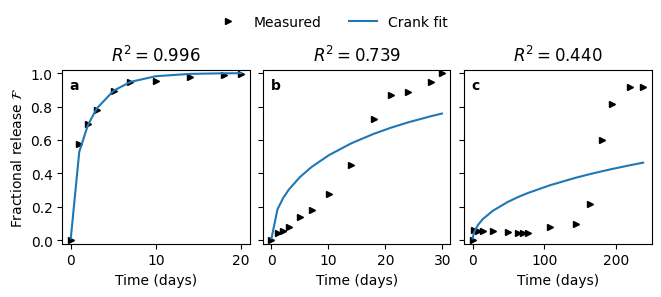

In [6]:
import matplotlib.lines as mlines

fig, axes = plt.subplots(1, 3, figsize=(6.5, 2.5),
                         sharey=True, constrained_layout=True)

for ax, idx, lab in zip(axes, indices_to_save, panel_labels):
    df_p, crank_pred, r2 = fit_cache[idx]
    ax.plot(df_p['Time'], df_p['Release'], marker='>', linestyle='None',
            color='black', markersize=4)
    ax.plot(df_p['Time'], crank_pred, color='#1f77b4', linestyle='-')

    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel(r"Time (days)")
    ax.set_title(fr"$R^2 = {r2:.3f}$")          # R² as panel title
    # panel letter stays, top-left inside the axes
    ax.text(0.04, 0.95, lab, transform=ax.transAxes, fontsize=10,
            fontweight='bold', va='top', ha='left')

axes[0].set_ylabel(r"Fractional release $\mathcal{F}$")

# ---- one shared legend, above the panels ----
handles = [
    mlines.Line2D([], [], color='black', marker='>', linestyle='None',
                  markersize=4, label='Measured'),
    mlines.Line2D([], [], color='#1f77b4', linestyle='-', label='Crank fit'),
]
fig.legend(handles=handles, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, 1.0), frameon=False)

fig.savefig("plots/fig4_crank_fits.pdf")
fig.savefig("plots/fig4_crank_fits.png", dpi=600)
plt.show()

In [7]:
df_summary.head()

,Formulation Index,Particle Radius,Crank_D,Crank_rmse,Crank_r2,Crank_rmse_weighted,Crank_r2_weighted
0,1,23.8615,7.085839e-19,0.248216,0.440382,0.273049,0.342680
1,2,0.9000,3.317616e-19,0.019209,0.995689,0.018260,0.989597
2,3,6.2500,4.404219e-18,0.105214,0.905010,0.095586,0.884433
3,4,14.6500,2.303906e-17,0.174696,0.797201,0.165255,0.763416
4,5,29.0000,7.836626e-17,0.177592,0.784883,0.165095,0.759998


In [8]:
df_summary.to_excel("plga_dataset/crank_fit.xlsx", index=False)

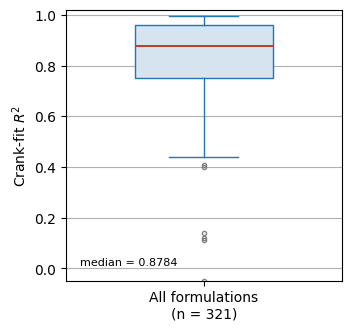

In [9]:
import numpy as np

fig, ax = plt.subplots(figsize=(3.4, 3.2), constrained_layout=True)   # single-column, near-square
r2 = df_summary['Crank_r2'].values
median = np.median(r2)
bp = ax.boxplot(r2, widths=0.5, patch_artist=True,
                medianprops=dict(color='#c0392b', linewidth=1.4),
                boxprops=dict(facecolor='#d6e4f0', edgecolor='#1f77b4', linewidth=1.0),
                whiskerprops=dict(color='#1f77b4', linewidth=1.0),
                capprops=dict(color='#1f77b4', linewidth=1.0),
                flierprops=dict(marker='o', markersize=3,
                                markerfacecolor='none', markeredgecolor='0.5'))
ax.set_ylabel(r"Crank-fit $R^2$")
ax.set_xticks([1])
ax.set_xticklabels(["All formulations\n(n = 321)"])
ax.set_ylim(-0.05, 1.02)
ax.grid(True, axis='y')          # horizontal gridlines only — vertical ones are meaningless here
# median value in the bottom-left corner, inside the axes
ax.text(0.05, 0.05, fr"median = {median:.4f}",
        transform=ax.transAxes, va='bottom', ha='left', fontsize=8)
fig.savefig("plots/fig5_crank_r2_distribution.pdf")
fig.savefig("plots/fig5_crank_r2_distribution.png", dpi=600)
plt.show()

In [10]:
print(f"Median : {df_summary['Crank_r2'].quantile(0.5)}")

Median : 0.8783925029732786


In [11]:
print(f"Interquartile range: {df_summary['Crank_r2'].quantile(0.75) - df_summary['Crank_r2'].quantile(0.25)}")

Interquartile range: 0.20856792871534036
